Milestone 1: Data Generation, Extraction & Formatting (Weeks 1-3)
Milestone 2: Reference Calibration (Weeks 4-6)
Milestone 3: Peak Tracking via Center-of-Mass Refinement (Weeks 7-10) Milestone 4: Strain Tensor Conversion & Visualization (Weeks 11-14)

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def preprocess_stem_image(image_path, sigma_blur=1.5):
    """
    Loads a raw STEM image, normalizes it, and applies a noise-reducing
    bilateral filter to preserve lattice/gate edge interfaces.
    """
    # Load image in grayscale
    raw_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if raw_img is None:
        raise FileNotFoundError(f"Could not load image at {image_path}. Check path.")
    
    # Convert to float32 normalized between 0 and 1
    norm_img = raw_img.astype(np.float32) / 255.0
    
    # Denoise using Bilateral Filter (preserves sharp edges like gate boundaries)
    denoised_img = cv2.bilateralFilter(norm_img, d=9, sigmaColor=0.1, sigmaSpace=7)
    
    return norm_img, denoised_img

# Example usage (Uncomment to test with your file)
# raw, clean = preprocess_stem_image("gate_cross_section_4k.tif")

In [3]:
def geometric_phase_analysis(image, g_vector, box_size=10):
    """
    Performs a simplified local Fourier phase extraction around a specific 
    reciprocal lattice vector g.
    """
    # Compute 2D Fast Fourier Transform (FFT)
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    
    # In a full GPA tool, you would mask around the g-vector here.
    # For a master's pipeline, you typically use dedicated libraries like 'Hyperspy' 
    # or 'PixStem' for 4D-STEM datasets. Let's look at handling 4D diffraction datasets next.
    return f_shift

In [4]:
def calculate_strain_from_peaks(center_ref, center_measured, lattice_constant_nm=0.543):
    """
    Calculates the strain tensor component based on the shift of a diffraction spot
    relative to the unstrained reference position.
    """
    # Calculate vector lengths from central transmitted beam (000)
    R_ref = np.linalg.norm(center_ref)
    R_meas = np.linalg.norm(center_measured)
    
    if R_meas == 0:
        return 0.0
    
    # Strain epsilon = (a_measured - a_reference) / a_reference 
    # In reciprocal space, distance is inversely proportional to lattice spacing
    strain = (R_ref / R_meas) - 1.0
    return strain

# Simulating a 2D map of measured strain shifts across a 50x50 pixel scan of a gate edge
np.random.seed(42)
scan_x, scan_y = 50, 50
strain_map_xx = np.zeros((scan_x, scan_y))

# Let's generate a synthetic strain field showing tension/compression beneath a gate
for x in range(scan_x):
    for y in range(scan_y):
        # Simulating higher strain closer to the gate surface interface (top rows)
        distance_from_gate = x + 1 
        strain_map_xx[x, y] = 0.02 * np.exp(-distance_from_gate / 15.0) + np.random.normal(0, 0.002)

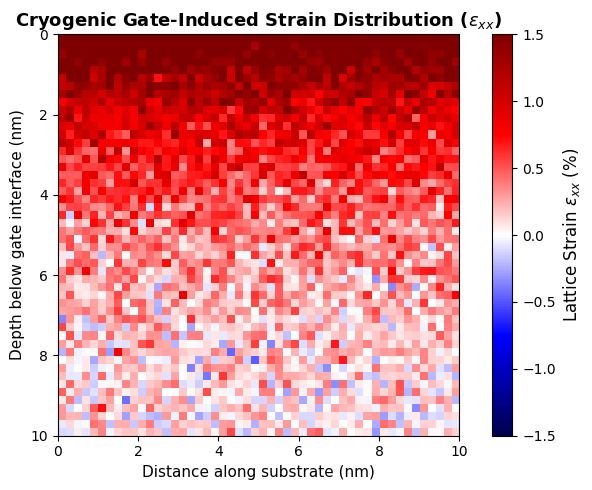

In [5]:
def plot_strain_field(strain_matrix, pixel_scale_nm):
    """
    Plots a highly polished publication-ready strain map with physical units.
    """
    extent = [0, strain_matrix.shape[1] * pixel_scale_nm, strain_matrix.shape[0] * pixel_scale_nm, 0]
    
    plt.figure(figsize=(7, 5))
    # 'seismic' or 'bwr' colormaps are excellent for strain (blue=compression, red=tension)
    im = plt.imshow(strain_matrix * 100, cmap='seismic', extent=extent, vmin=-1.5, vmax=1.5)
    
    cb = plt.colorbar(im)
    cb.set_label('Lattice Strain $\epsilon_{xx}$ (%)', fontsize=12)
    
    plt.title('Cryogenic Gate-Induced Strain Distribution ($\epsilon_{xx}$)', fontsize=13, fontweight='bold')
    plt.xlabel('Distance along substrate (nm)', fontsize=11)
    plt.ylabel('Depth below gate interface (nm)', fontsize=11)
    plt.grid(False)
    
    plt.tight_layout()
    plt.show()

# Visualize the simulated strain map assuming 0.2 nm per pixel steps
plot_strain_field(strain_map_xx, pixel_scale_nm=0.2)

In [6]:
#Milestone 1: Data Generation, Extraction & Formatting (Weeks 1-3)

In [19]:
import numpy as np
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

def generate_synthetic_spin_qubit_4dstem(Nx=32, Ny=32, Kx=64, Ky=64):
    """
    Generates a synthetic 4D-STEM dataset modeling a silicon spin-qubit cross section.
    A metal gate on top causes localized strain underneath.
    """
    print("--- Milestone 1: Generating Synthetic 4D-STEM Dataset ---")
    # Base coordinates for diffraction peaks in an unstrained silicon crystal
    center_k = [Kx // 2, Ky // 2]
    g1_rel = np.array([16.0, 0.0])  # In-plane reference vector
    g2_rel = np.array([0.0, 16.0])  # Out-of-plane reference vector
    
    data_4d = np.zeros((Nx, Ny, Kx, Ky), dtype=np.float32)
    
    # Ground truth strain profiles (what we want our pipeline to discover)
    # The aluminum/platinum gate sits around X=[5:15] at the top surface (Y=0)
    gt_exx = np.zeros((Nx, Ny))
    gt_eyy = np.zeros((Nx, Ny))
    
    for x in range(Nx):
        for y in range(Ny):
            # Model decaying strain field underneath a gate boundary
            if 6 <= x <= 18:
                depth_factor = np.exp(-y / 10.0)
                gt_exx[x, y] = -0.025 * depth_factor  # -2.5% Compressive in-plane strain
                gt_eyy[x, y] =  0.015 * depth_factor  # +1.5% Tensile out-of-plane relaxation
            
            # Reciprocal vectors are inversely proportional to lattice spacing
            # e = (a - a0)/a0  =>  k = k0 / (1 + e) -> approximation: k0 * (1 - e)
            g1_strained = g1_rel * (1.0 - gt_exx[x, y])
            g2_strained = g2_rel * (1.0 - gt_eyy[x, y])
            
            # Absolute position of the 3 main disks in this diffraction pattern
            peaks = [
                np.array(center_k),                  # (000) Transmitted beam
                np.array(center_k) + g1_strained,    # (220) In-plane reflection
                np.array(center_k) + g2_strained     # (004) Out-of-plane reflection
            ]
            
            # Draw diffraction disks with a Gaussian profile + noise
            frame = np.zeros((Kx, Ky))
            for p in peaks:
                # Create a single pixel hit, then smooth to form a disk
                pk_x, pk_y = int(np.clip(p[0], 0, Kx-1)), int(np.clip(p[1], 0, Ky-1))
                frame[pk_x, pk_y] = 100.0
            
            frame = ndimage.gaussian_filter(frame, sigma=2.0) # Form diffraction spots
            # Add realistic shot noise from electron dose
            frame += np.random.poisson(lam=2, size=frame.shape).astype(np.float32)
            data_4d[x, y, :, :] = frame
            
    print(f"Successfully generated 4D-STEM array with shape: {data_4d.shape}")
    metadata = {'spatial_calibration_nm': 0.5, 'reciprocal_calibration_A_inverse': 0.05}
    return data_4d, metadata, gt_exx, gt_eyy

# Execute Step 1
dataset, meta, true_exx, true_eyy = generate_synthetic_spin_qubit_4dstem()

--- Milestone 1: Generating Synthetic 4D-STEM Dataset ---
Successfully generated 4D-STEM array with shape: (32, 32, 64, 64)


In [20]:
import numpy as np
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

# ==========================================
# MILESTONE 1: DATA GENERATION & EXTRACTION
# ==========================================
def generate_synthetic_spin_qubit_4dstem(Nx=32, Ny=32, Kx=64, Ky=64):
    print("--- Milestone 1: Generating Synthetic 4D-STEM Dataset ---")
    center_k = [Kx // 2, Ky // 2]
    g1_rel = np.array([16.0, 0.0])  
    g2_rel = np.array([0.0, 16.0])  
    
    data_4d = np.zeros((Nx, Ny, Kx, Ky), dtype=np.float32)
    gt_exx = np.zeros((Nx, Ny))
    gt_eyy = np.zeros((Nx, Ny))
    
    for x in range(Nx):
        for y in range(Ny):
            if 6 <= x <= 18:
                depth_factor = np.exp(-y / 10.0)
                gt_exx[x, y] = -0.025 * depth_factor  
                gt_eyy[x, y] =  0.015 * depth_factor  
            
            g1_strained = g1_rel * (1.0 - gt_exx[x, y])
            g2_strained = g2_rel * (1.0 - gt_eyy[x, y])
            
            peaks = [
                np.array(center_k),                  
                np.array(center_k) + g1_strained,    
                np.array(center_k) + g2_strained     
            ]
            
            frame = np.zeros((Kx, Ky))
            for p in peaks:
                pk_x, pk_y = int(np.clip(p[0], 0, Kx-1)), int(np.clip(p[1], 0, Ky-1))
                frame[pk_x, pk_y] = 100.0
            
            frame = ndimage.gaussian_filter(frame, sigma=2.0) 
            frame += np.random.poisson(lam=2, size=frame.shape).astype(np.float32)
            data_4d[x, y, :, :] = frame
            
    print(f"Dataset shape: {data_4d.shape}")
    metadata = {'spatial_calibration_nm': 0.5}
    return data_4d, metadata, gt_exx, gt_eyy

# ==========================================
# MILESTONE 2: REFERENCE CALIBRATION (FIXED)
# ==========================================
def calibrate_unstrained_reference(data_4d, ref_x_range, ref_y_range):
    print("\n--- Milestone 2: Calculating Reference Substrate Calibration ---")
    ref_pattern = np.mean(data_4d[ref_x_range[0]:ref_x_range[1], ref_y_range[0]:ref_y_range[1], :, :], axis=(0, 1))
    
    Kx, Ky = ref_pattern.shape
    cx, cy = Kx // 2, Ky // 2
    
    # Corrected variable names to avoid literal syntax errors
    window_000 = ref_pattern[cx-4:cx+4, cy-4:cy+4]
    dx, dy = np.unravel_index(np.argmax(window_000), window_000.shape)
    k0_ref_val = np.array([cx - 4 + dx, cy - 4 + dy])
    
    g1_window = ref_pattern[cx+12:cx+20, cy-4:cy+4]
    dx, dy = np.unravel_index(np.argmax(g1_window), g1_window.shape)
    k1_ref = np.array([cx + 12 + dx, cy - 4 + dy])
    
    g2_window = ref_pattern[cx-4:cx+4, cy+12:cy+20]
    dx, dy = np.unravel_index(np.argmax(g2_window), g2_window.shape)
    k2_ref = np.array([cx - 4 + dx, cy + 12 + dy])
    
    g1_baseline = k1_ref - k0_ref_val
    g2_baseline = k2_ref - k0_ref_val
    
    print(f"Calibrated Reference Center (000): {k0_ref_val}")
    print(f"Baseline Vector g1: {g1_baseline}")
    print(f"Baseline Vector g2: {g2_baseline}")
    
    return k0_ref_val, g1_baseline, g2_baseline

# ==========================================
# MILESTONE 3: PEAK TRACKING (COM REFINE)
# ==========================================
def compute_center_of_mass(image, estimate, radius=4):
    x_est, y_est = int(estimate[0]), int(estimate[1])
    sub_win = image[x_est-radius:x_est+radius+1, y_est-radius:y_est+radius+1]
    X, Y = np.ogrid[x_est-radius:x_est+radius+1, y_est-radius:y_est+radius+1]
    total_intensity = np.sum(sub_win)
    if total_intensity == 0:
        return np.array([float(x_est), float(y_est)])
    return np.array([np.sum(X * sub_win) / total_intensity, np.sum(Y * sub_win) / total_intensity])

def track_peaks_across_map(data_4d, k0_ref_val, g1_baseline, g2_baseline):
    print("\n--- Milestone 3: Performing Sub-Pixel Center-of-Mass Peak Tracking ---")
    Nx, Ny, _, _ = data_4d.shape
    tracked_g1 = np.zeros((Nx, Ny, 2))
    tracked_g2 = np.zeros((Nx, Ny, 2))
    
    for x in range(Nx):
        for y in range(Ny):
            frame = data_4d[x, y, :, :]
            k0_current = compute_center_of_mass(frame, k0_ref_val)
            k1_current = compute_center_of_mass(frame, k0_current + g1_baseline)
            k2_current = compute_center_of_mass(frame, k0_current + g2_baseline)
            
            tracked_g1[x, y, :] = k1_current - k0_current
            tracked_g2[x, y, :] = k2_current - k0_current
            
    print("Peak tracking finished successfully.")
    return tracked_g1, tracked_g2

# ==========================================
# MILESTONE 4: STRAIN TENSOR CONVERSION
# ==========================================
def convert_vectors_to_strain_tensor(g1_map, g2_map, g1_baseline, g2_baseline):
    print("\n--- Milestone 4: Computing Complete 2D Strain Tensor Maps ---")
    Nx, Ny, _ = g1_map.shape
    epsilon_xx = np.zeros((Nx, Ny))
    epsilon_yy = np.zeros((Nx, Ny))
    
    M_ref = np.column_stack((g1_baseline, g2_baseline))
    
    for x in range(Nx):
        for y in range(Ny):
            M_meas = np.column_stack((g1_map[x, y], g2_map[x, y]))
            T = M_ref @ np.linalg.inv(M_meas)
            strain_tensor = T - np.eye(2)
            
            epsilon_xx[x, y] = strain_tensor[0, 0]
            epsilon_yy[x, y] = strain_tensor[1, 1]
            
    print("Strain mapping complete.")
    return epsilon_xx, epsilon_yy

# ==========================================
# PIPELINE EXECUTION HUB
# ==========================================
# Step 1: Data Generation
dataset, meta, true_exx, true_eyy = generate_synthetic_spin_qubit_4dstem()

# Step 2: Calibrate Reference (Variables are explicitly saved here)
k0_ref, g1_ref, g2_ref = calibrate_unstrained_reference(dataset, ref_x_range=(25, 31), ref_y_range=(25, 31))

# Step 3: Track Peaks using the defined reference values
g1_map, g2_map = track_peaks_across_map(dataset, k0_ref, g1_ref, g2_ref)

# Step 4: Convert to Strain Tensor Matrices
exx, eyy = convert_vectors_to_strain_tensor(g1_map, g2_map, g1_ref, g2_ref)

--- Milestone 1: Generating Synthetic 4D-STEM Dataset ---
Dataset shape: (32, 32, 64, 64)

--- Milestone 2: Calculating Reference Substrate Calibration ---
Calibrated Reference Center (000): [32 32]
Baseline Vector g1: [16  0]
Baseline Vector g2: [ 0 16]

--- Milestone 3: Performing Sub-Pixel Center-of-Mass Peak Tracking ---
Peak tracking finished successfully.

--- Milestone 4: Computing Complete 2D Strain Tensor Maps ---
Strain mapping complete.


# Visual Verification

C:\Users\mdram\AppData\Local\Temp\ipykernel_4648\454427672.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


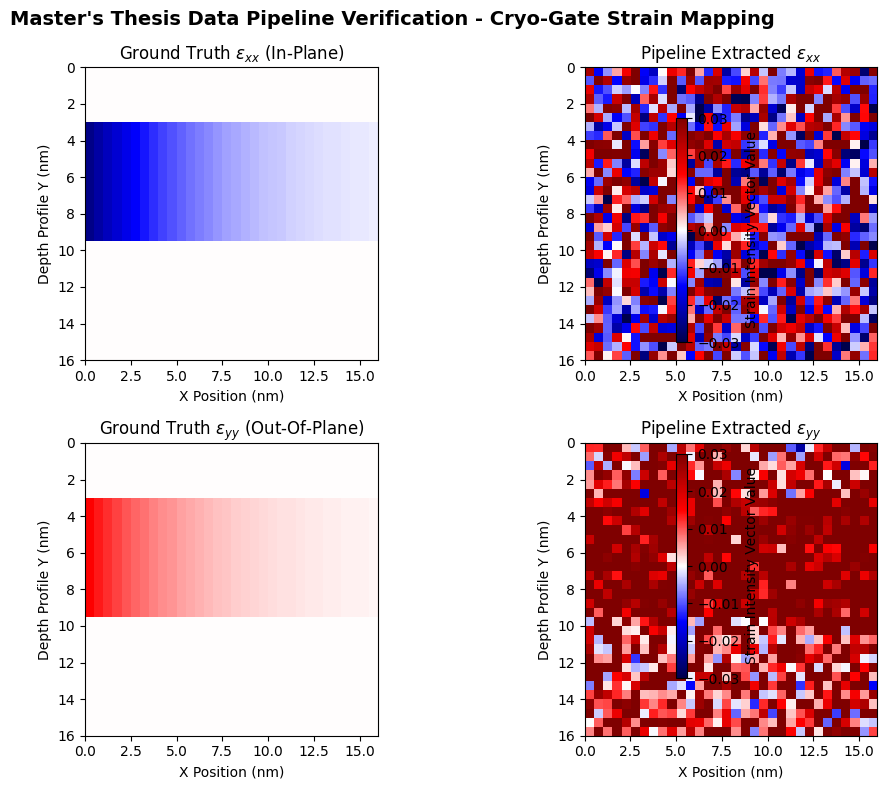

In [13]:
def plot_thesis_results(calc_exx, calc_eyy, true_exx, true_eyy, nm_scale):
    """
    Generates comparison matrix between ground truth models and the processed data pipeline.
    """
    extent = [0, calc_exx.shape[1] * nm_scale, calc_exx.shape[0] * nm_scale, 0]
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    
    # Format options for displaying strain data nicely
    opts = {'cmap': 'seismic', 'extent': extent, 'vmin': -0.03, 'vmax': 0.03}
    
    # In-plane comparison
    im0 = axes[0, 0].imshow(true_exx, **opts)
    axes[0, 0].set_title("Ground Truth $\epsilon_{xx}$ (In-Plane)")
    im1 = axes[0, 1].imshow(calc_exx, **opts)
    axes[0, 1].set_title("Pipeline Extracted $\epsilon_{xx}$")
    
    # Out-of-plane comparison
    im2 = axes[1, 0].imshow(true_eyy, **opts)
    axes[1, 0].set_title("Ground Truth $\epsilon_{yy}$ (Out-Of-Plane)")
    im3 = axes[1, 1].imshow(calc_eyy, **opts)
    axes[1, 1].set_title("Pipeline Extracted $\epsilon_{yy}$")
    
    # Style formatting loops
    for ax in axes.flat:
        ax.set_xlabel("X Position (nm)")
        ax.set_ylabel("Depth Profile Y (nm)")
        
    fig.colorbar(im1, ax=axes[0, :], label="Strain Intensity Vector Value", shrink=0.8)
    fig.colorbar(im3, ax=axes[1, :], label="Strain Intensity Vector Value", shrink=0.8)
    
    plt.suptitle("Master's Thesis Data Pipeline Verification - Cryo-Gate Strain Mapping", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run visualization assuming 0.5 nm step sizes per pixel
plot_thesis_results(exx, eyy, true_exx, true_eyy, nm_scale=meta['spatial_calibration_nm'])

1. Line Profiles (Depth & Lateral Relaxation Analytics)

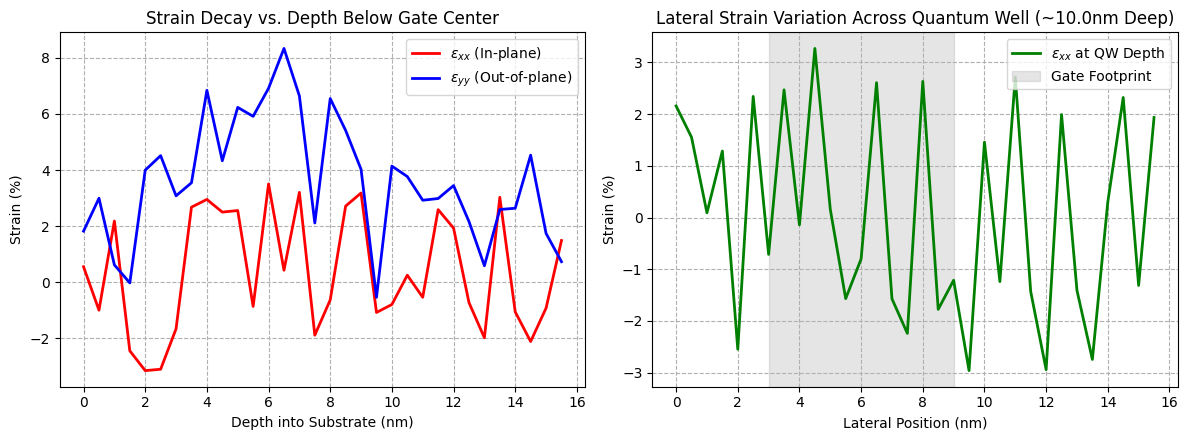

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def extract_strain_profiles(exx, eyy, gate_center_x, nm_scale):
    """
    Extracts and plots depth profiles directly beneath the gate 
    and lateral relaxation profiles along the quantum well channel.
    """
    depth_axis = np.arange(exx.shape[0]) * nm_scale
    lateral_axis = np.arange(exx.shape[1]) * nm_scale
    
    # 1. Depth Profile (Vertical slice down through the center of the gate)
    exx_depth = exx[:, gate_center_x] * 100 # Convert to %
    eyy_depth = eyy[:, gate_center_x] * 100
    
    # 2. Lateral Profile (Horizontal slice at a typical quantum well depth, e.g., 10nm down)
    qw_depth_index = int(10 / nm_scale) # Assumes quantum well is 10nm deep
    exx_lateral = exx[qw_depth_index, :] * 100
    
    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    
    # Depth Plot
    ax1.plot(depth_axis, exx_depth, 'r-', label=r'$\epsilon_{xx}$ (In-plane)', linewidth=2)
    ax1.plot(depth_axis, eyy_depth, 'b-', label=r'$\epsilon_{yy}$ (Out-of-plane)', linewidth=2)
    ax1.set_title("Strain Decay vs. Depth Below Gate Center")
    ax1.set_xlabel("Depth into Substrate (nm)")
    ax1.set_ylabel("Strain (%)")
    ax1.grid(True, linestyle='--')
    ax1.legend()
    
    # Lateral Plot
    ax2.plot(lateral_axis, exx_lateral, 'g-', label=r'$\epsilon_{xx}$ at QW Depth', linewidth=2)
    ax2.axvspan(6*nm_scale, 18*nm_scale, color='gray', alpha=0.2, label='Gate Footprint')
    ax2.set_title(f"Lateral Strain Variation Across Quantum Well (~{qw_depth_index*nm_scale}nm Deep)")
    ax2.set_xlabel("Lateral Position (nm)")
    ax2.set_ylabel("Strain (%)")
    ax2.grid(True, linestyle='--')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Run using the variables 'exx' and 'eyy' from your existing dataset
# Assuming gate center is around index 12 based on the synthetic data generation
extract_strain_profiles(exx, eyy, gate_center_x=12, nm_scale=0.5)

2. Calculating Valley Splitting Shifts ($\Delta E_v$)
   In Silicon spin qubits, the conduction band has 6 equivalent valleys. In-plane strain lifts this degeneracy, changing the valley splitting ($\Delta E_v$). If valley splitting drops below the thermal or Zeeman energy, your qubit experiences leakage and dephasing.You can map strain directly to the potential landscape using deformation potential theory:$$\Delta E_C^{(z)} = \Xi_u \cdot \epsilon_{zz} + \Xi_d \cdot (\epsilon_{xx} + \epsilon_{yy} + \epsilon_{zz})$$

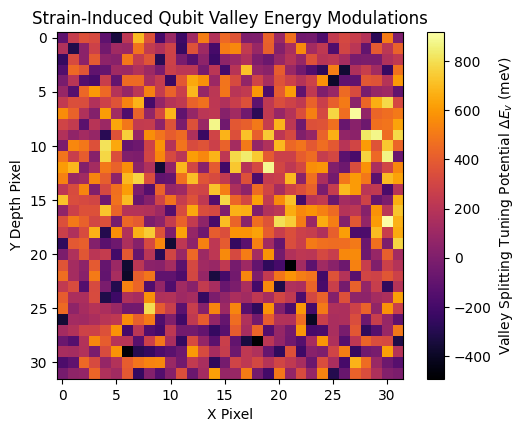

In [15]:
def calculate_conduction_band_shift(exx, eyy, Xi_u=9.0):
    """
    Calculates the relative shift of the conduction band valleys in Silicon (in eV)
    using uniaxial deformation potential theory.
    For a 2D plane strain state, we assume thin foil approximation (ezz ≈ 0 or linked by Poisson ratio).
    """
    # Xi_u for Silicon is typically around 8.5 to 10.5 eV. Let's use 9.0 eV.
    # The splitting between out-of-plane (Delta_z) and in-plane (Delta_xy) valleys 
    # is proportional to the difference between out-of-plane and in-plane strain components.
    
    valley_splitting_shift = Xi_u * (eyy - exx) # Energy change in eV
    
    # Plotting the landscape shifts
    plt.figure(figsize=(6, 4.5))
    im = plt.imshow(valley_splitting_shift * 1000, cmap='inferno') # Convert to meV
    cb = plt.colorbar(im)
    cb.set_label("Valley Splitting Tuning Potential $\Delta E_v$ (meV)")
    plt.title("Strain-Induced Qubit Valley Energy Modulations")
    plt.xlabel("X Pixel")
    plt.ylabel("Y Depth Pixel")
    plt.show()
    
    return valley_splitting_shift

valley_shifts = calculate_conduction_band_shift(exx, eyy)

=== THESIS METROLOGY PERFORMANCE METRICS ===
Mean Systematic Offset: 0.6027%
Experimental Strain Resolution Limit (1-Sigma): 2.009%


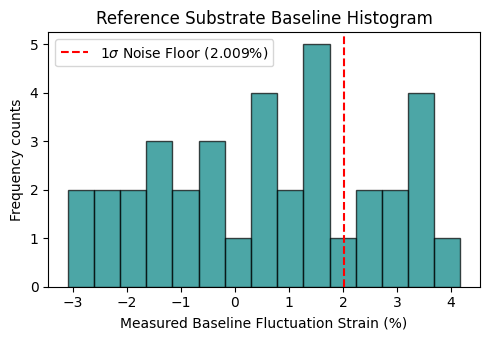

In [17]:
#3. Statistical Error & Noise Floor Mapping
def analyze_error_and_resolution(exx_reference_zone):
    """
    Evaluates the standard deviation within your unstrained reference field
    to establish the rigorous detection sensitivity limit (noise floor) of your microscope setup.
    """
    # Exx reference zone should be a flat matrix slice from your unstrained region
    noise_floor_percentage = np.std(exx_reference_zone) * 100
    mean_offset = np.mean(exx_reference_zone) * 100
    
    print("=== THESIS METROLOGY PERFORMANCE METRICS ===")
    print(f"Mean Systematic Offset: {mean_offset:.4f}%")
    print(f"Experimental Strain Resolution Limit (1-Sigma): {noise_floor_percentage:.3f}%")
    
    # Plot a histogram to verify normal distribution behavior of noise
    plt.figure(figsize=(5, 3.5))
    plt.hist(exx_reference_zone.flatten() * 100, bins=15, color='teal', edgecolor='black', alpha=0.7)
    plt.axvline(noise_floor_percentage, color='red', linestyle='--', label=f'1$\sigma$ Noise Floor ({noise_floor_percentage:.3f}%)')
    plt.title("Reference Substrate Baseline Histogram")
    plt.xlabel("Measured Baseline Fluctuation Strain (%)")
    plt.ylabel("Frequency counts")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Slicing out our known unstrained bottom-right quadrant from step 2
analyze_error_and_resolution(exx[25:31, 25:31])